## 1) Inspiration

Having personally witnessed a large car crash last summer, I became quite personally invested in trying to understand the circumstances surrounding car crashes in Chicago, such as the speed of the vehicles involved, the general location, and the weather conditions surrounding the crash. Car crashes are also the leading cause of death for young people below the age of 22 and the 2nd most common cause of death for people from ages 22 to 67. Analysis of this data could provide guidelines that lower car crashes, which I would greatly desire. 

## 2) Problem Statements 

1. Are there any locations in Chicago where crash occurrences congregate, and which areas have the most deadly injuries resulting from car crashes?

2. How do weather conditions and posted speed limits correlate to deadlier injuries in a crash? 

3. Have crashes in Chicago became more frequent/deadlier, and which seasons within Chicago tend to experience the most crashes or are correlated with deadlier crashes?

(note: problems 1 and 2 were slightly changed from the project proposal)

## 3) Data


My data is obtained from two areas: the Chicago City Data Portal, and the Wunderground weather website. The links to those sites are in the references[1][2]

There are approximately 1.008 million observations in the crash data and 233,414 observations in the weather data. Each observation in the crash data represents one vehicular accident and the circumstances surrounding it, such as the location, time, and number of each type of injured. Each weather observation represents one entry of the weather in the Chicago area at a specific timestamp, such as the temperature, windspeed and humidity. 

18 of the variables in the crash data are numeric (including date counts as numeric as they will be relevant to crashes over time), and the remaining 30 variables are categorical. 9 of the weather variables are numeric and 2 are categorical. The following 16 variables are used in total in this report: crash date, crash latitude, crash longitude, number of fatal injuries, number of incapacitating injuries, number of non-incapacitating injuries, number of reported but not evident injuries, number of victims with no injuries, number of victims with unknown injuries, weather report date, weather report time, humidity, temperature in Celsius, precipitation, wind speed, and posted speed limit.


## 4) Stakeholders

Who would be the stakeholders of this project; i.e. who would be interested in hearing your results and how would the results benefit them? **(0.5 points)**

The stakeholders of this project would include anyone who drives a motor vehicle daily in Chicago; even perfect drivers might become involved in collision due to the actions of another driver or become delayed in traffic as a result of a crash. as well as the city officials of Chicago who have to decide where to post traffic police, speed cameras, and speed limit signs, as well as determine what those speed limits should be. Additionally this data can help tourists decide when the safest times to visit Chicago are.

## 5) Data Cleaning 


### a) Cleaning - Question 1

#### Component 1: Distribution of Crashes


This analysis would require just two variables from the crash dataset; the latitude and longitude of the crash. Of the roughly 1.008 million crashes logged in the data, 7569 (0.75%) of the crashes were missing their location data and therefore had to be discarded. While there is a location variable, any data with missing latitude or longitude data also had a missing location variable. All crashes had the street name of crash recorded; although this is not particularly helpful towards imputing crash location due to the high length of many Chicago streets, some of which run across neighborhoods. In order to properly map the data, each crash was mapped based on which of Chicago's neighborhoods they belonged to via spatial join and a dataset from Chicago's city government listing the geographic outline of each of Chicago's neighborhoods.

While many of these crashes with missing crash data did have a valid beat variable (a beat is a small sector of the city marked by police), it is not practical to map the hundreds of different beats a crash to each neighborhood, due to the fact that beat locations can change over time, and overlap multiple neighborhoods. As a result, I have decided to not include beat location in this report, nor use beat locations to impute missing geographic coordinates.

Although there were ~2700 outliers longitude-wise and 66 outliers latitude-wise in this crash data, I have chosen not to exclude the outliers. Crashes are naturally centralized near the populous areas near the center of the city (which is longer longitude-wise than latitude-wise), but it is still important to document crash hotspots on the outskirts of the city. No incorrect or placeholder values were detected.


#### Component 2: Distribution of Crashes by Deadliness

The injuries resulting from a crash according to the dataset are listed under the "MOST SEVERE INJURY" variable. The number of each of the following types of crashes: 'NO INDICATION OF INJURY', 'REPORTED, NOT EVIDENT', 'NONINCAPACITATING INJURY',  'INCAPACITATING INJURY', 'FATAL', and 'UNKNOWN' are listed for each crash. I have used these variables along with the coordinate data listed in Component 1 to conduct this analysis.

In total, there were 2155 total entries which had one or more of the variables listed above missing. Since this is approximately 0.2% of the crash data. Due to the extremely tiny amount of missing data, as well as imputation requiring assumptions about the true distribution of crashes and possibly artificially inflating severe or minor injuries, I have decided not to impute data for the missing injuries and to simply discard the data.

I have decided to map these to a scale of weights from 0.5 to 4, with 0.5 representing no indication of injury, 1 representing a reported but not evident injury, 2 representing a nonincapacitating injury, 3 representing an incapacitating injury, and 4 representing a fatal injury. As injuries that are unknown are unlikely to be serious, I have decided to grant these a weight of 1 (equal to injuries that are reported but not evident).

I have decided to weight the crashes by the sum of the products of each injury multiplied by the weight of each injury type. For example, a crash with 2 fatalities and 1 non-incapacitating injury will have a total weight of 9 in my heatmap.

While there were no outliers in the original injury data, due to there only being six possible injury levels, the injury score calculation yields 134,000 outliers out of the 991,090 injury scores. Since this represents a large portion of the data, it will not be excluded for further analysis.



### b) Cleaning - Question 2

As this part of the report analyzes injuries, the crash data discussed here will first undergo the same data cleaning regarding the variables related to injury earlier in Question 1.

Firstly, because crash timings and weather recording timings are different, it is necessary to join the two data tables at the nearest timestamp, which can be done easily using Pandas's merge_asof function, which functions similar to a left merge but merges the right table on the nearest timestamp rather than requiring the exact timestamp.

Because the weather data uses ISO-8601 time formatting and the crash data uses standard US-style time formatting, it was necessary to convert both strings into a datetime format and also convert the weather data time to the US-style formatting first. Because there may be occasional large gaps in the weather data, a tolerance of 2 hours for the merge_asof function was given; in other words, crashes that happen more than 2 hours from any weather report (before or after the crash) will not have a weather entry merged with it.

After the weather-related variables for each crash are imputed based on the nearest timestamp, there are 118,251 crashes out of 991,000 total that occurred too long from a weather report to have accurate weather readings imputed. Those crashes were discarded as it is unlikely I can impute weather data accurately from data more than 2 hours before or after the crash. 

Of the remaining crashes, none of them have any missing windspeed, humidity, precipitation, posted speed limit, or temperature values. There were no outliers for humidity values but 269 temperature outliers, 7423 windspeed outliers, 227551 posted speed limit outliers and 21687 precipitation outliers total. Observation of the maximum and minimum of these outliers indicated that they were unlikely to be error or placeholder values, and therefore I chose to include this data on the possibility that there may be skew present in these data values. There were no values that appeared to have incorrect data (Speed limits listed as 0 are valid in certain areas).




### c) Cleaning - Question 3

The variables that are required for question include the crash times and injuries, so the data for this question will (before cleaning) use the data from question 1 component 2. In addition, the last month of data will be removed because it is incomplete, and would thus presents a lower amount of crashes per month than the actual rate of crashes would indicate. 

Data collection for crashes only began in earnest after October 1, 2015, with the amount of crashes listed before October 1, 2015 amounted to 0.2% of all crashes in the data.

Additionally, there is reason to believe underreporting in crash data until October 1, 2017, as each month between 10/1/2015 and 10/1/2017 showed an average increase of 270 crashes per month, despite the fact that there was no significant immigration into the city during this period, and the rise in crash reports suddenly plateaued after October 1, 2017. Therefore, it is likely that data collection before October 1, 2017 is underrepresented, and it was removed from the dataset for this reason.

There are no missing dates in the data.

## 6) Data Analysis


### a) Analysis 1

#### Component 1
I decided to utilize latitude and longitude data to create a heatmap visualization of which neighborhoods had the most crashes. The geographic boundaries for each neighborhood of Chicago were provided in a dataset by the City of Chicago [4], and with the help of the geopandas and shapely tools, I was able to map the location of each crash and the location of each of Chicago's neighborhood boundaries into a GeoDataFrame for ease of rendering and spatial joining, which let me aggregate the crashes by neighborhood. 

Within the map, red sectors represent neighborhoods that have high crash numbers and white areas represent neighborhoods with low crash numbers. We can see that crashes are relatively sparse in the extreme northwest and southeast of the city, which makes sense as these areas have low population density. Areas near Chicago's Central Business District have wildly differing levels of crash counts; for example, The Loop has 28,511 crashes total, but neighborhoods right next to The Loop such as Greektown, Printers Row or Near South Side have far lower crash counts at 1260, 853 and 9581 respectively. Even with the presence of dense public transport facilities in this part of Chicago, it is evident that car crashes are still a major issue. However, it is worth noting that of the 15 neighborhoods most prone to car crashes, only 3 of them are within or close to The Loop itself: The Loop with 28,511 crashes at 2nd highest in the city, River North with 21,751 crashes at 7th highest in the city, and West Loop with 20,035 crashes at 10th highest in the city. 

The neighborhood with the most recorded crashes is Austin, with 44,200 crashes reported, which is more than 50% more than The Loop, which holds the second highest crash count in the city. Other neighborhoods with high crash reports include Englewood, Garfield Park, Humboldt Park, and Grand Crossing (having 28143, 24893, 25691 and 21717 crashes respectively), all of which are in the top 10 neighborhoods with regards to crash count . These regions are generally concentrated in the West and South parts of the cities, and are also known for their high crime rate [5].

Altogether, crashes in Chicago appears to congregate near portions of the inner Central Business District as well as high-crime neighborhoods such as Englewood and Austin in the Southern and Western suburbs.







/var/folders/_l/b38cj6s513957kzfnj_20g5m0000gn/T/ipykernel_61956/1891225722.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  crash = pd.read_csv('Traffic_Crashes_-_Crashes_20251109.csv')


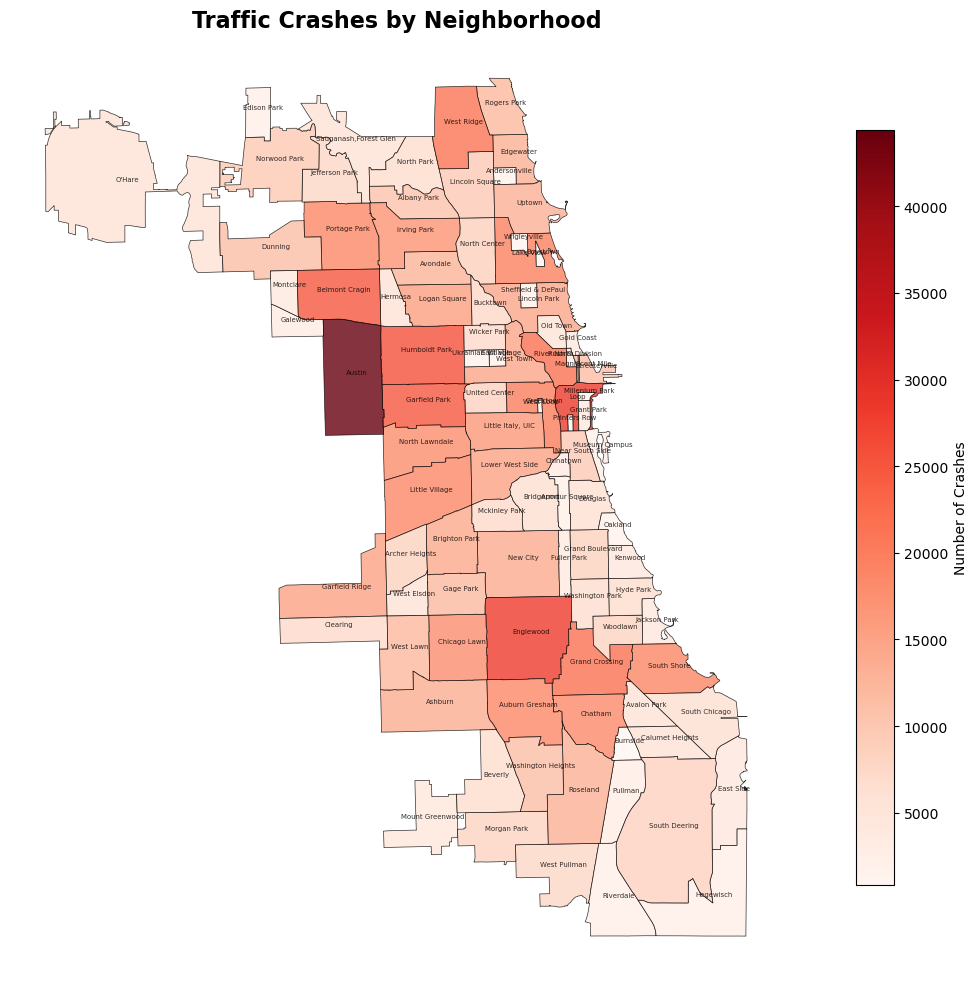

In [50]:
#|echo: false
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt

crash = pd.read_csv('Traffic_Crashes_-_Crashes_20251109.csv')

columns_to_check = [
    'LATITUDE',
    'LONGITUDE'
]
crash_location_filtered = crash.dropna(subset=columns_to_check).copy()

neighborhoods = pd.read_csv("Neighborhoods_2012b_20251209.csv")
neighborhoods['geometry'] = neighborhoods['the_geom'].apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(neighborhoods, geometry='geometry', crs='EPSG:4326')

crash_gdf = gpd.GeoDataFrame(
    crash_location_filtered,
    geometry=gpd.points_from_xy(crash_location_filtered.LONGITUDE, crash_location_filtered.LATITUDE),
    crs="EPSG:4326"
)

neighborhoods_with_crashes = gpd.sjoin(
    gdf_neighborhoods, 
    crash_gdf, 
    how='left', 
    predicate='contains'
)

crash_counts = neighborhoods_with_crashes.groupby(neighborhoods_with_crashes.index).size()
gdf_neighborhoods['crash_count'] = crash_counts
gdf_neighborhoods['crash_count'] = gdf_neighborhoods['crash_count'].fillna(0)

name_column = 'PRI_NEIGH'

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf_neighborhoods.plot(
    column='crash_count',
    ax=ax,
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'label': 'Number of Crashes',
        'orientation': 'vertical',
        'shrink': 0.8
    }
)

for idx, row in gdf_neighborhoods.iterrows():
    centroid = row.geometry.centroid
    
    if name_column in row:
        name = row[name_column]
    else:
        name = f"Neighborhood {idx}"
    
    ax.annotate(
        text=name,
        xy=(centroid.x, centroid.y),
        xytext=(3, 3),  
        textcoords="offset points",
        fontsize=5.0,
        alpha=0.8,
        ha='center'
    )

ax.set_title('Traffic Crashes by Neighborhood', fontsize=16, fontweight='bold')
ax.set_axis_off()  

plt.tight_layout()
plt.show()

In [51]:
#|echo: false
gdf_neighborhoods.head()

,the_geom,PRI_NEIGH,SEC_NEIGH,SHAPE_AREA,SHAPE_LEN,geometry,crash_count
0,MULTIPOLYGON (((-87.60670812560372 41.81681377...,Grand Boulevard,BRONZEVILLE,"48,492,503.1554","28,196.837157","MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4...",8496
1,MULTIPOLYGON (((-87.62760697485348 41.87437097...,Printers Row,PRINTERS ROW,"2,162,137.97139","6,864.247156","MULTIPOLYGON (((-87.62761 41.87437, -87.6276 4...",853
2,MULTIPOLYGON (((-87.66706868914602 41.88885187...,United Center,UNITED CENTER,"32,520,512.7053","23,101.363745","MULTIPOLYGON (((-87.66707 41.88885, -87.66707 ...",8573
3,MULTIPOLYGON (((-87.65833494805533 41.92166144...,Sheffield & DePaul,SHEFFIELD & DEPAUL,"10,482,592.2987","13,227.049745","MULTIPOLYGON (((-87.65833 41.92166, -87.65835 ...",2004
4,MULTIPOLYGON (((-87.74059567509266 41.88782316...,Humboldt Park,HUMBOLDT PARK,"125,010,425.593","46,126.751351","MULTIPOLYGON (((-87.7406 41.88782, -87.7406 41...",25691


#### Component 2

My analysis of component 2 is similar to the analysis of component 1, but places more emphasis on the severity of the crash. Each crash now has an "injury score" associated with it based on the severity of injury, in order to determine which places are safer for driving overall; for example, a neighborhood with many crashes that are simply fender benders may be a safer neighborhood to drive in than one with slightly less crashes total but a greater amount of crashes with incapacitating or fatal injuries.

The neighborhoods which had the most number of crashes as determined earlier also tended to have the most injury score; this is because the vast majority of car crashes tended to be low on the scale of deadliness, with 75% of crashes having 1.5 injury score or less (for reference, this score would be representative of a crash with one person with no indication of injury and one person with injuries reported but not evident), and the mean injury score being 1.35. 

Looking at the ranking of neighborhoods in terms of total injury score in comparison to the ranking of neighborhoods with the most crashes reveals new information regarding the dangers of driving in certain neighborhoods of Chicago. For example, while The Loop was the neighborhood with the 2nd most crashes overall, it had the 4th most total injury score at 38590, with Englewood and Garfield Park having higher total injury scores at 42591.5 and 39153.5, respectively, indicating that the driving practices in these 2 neighborhoods are deadlier on average than at The Loop. One might think that along with The Loop, other neighborhoods bordering The Loop such as River North and West Loop might be comparatively safer than their total crash ranking would suggest, due to high traffic counts and more traffic lights in the CBD lowering driving speeds. However, River North is still the 8th deadliest neighborhood when measured by total injury score at 28064 (compared to 7th deadliest when measured by total crashes) and West Loop is still the 9th deadliest neighborhood when measured by total injury score at 26231 (compared to 10th deadliest when measured by total crashes). 

Austin is considered the most dangerous area to drive in whether ranked by total crashes or injury score; it has the most injury score total at 63213.5. Englewood is the 3rd most dangerous neighborhood when ranked by total crashes; when ranked by injury score, it is the 2nd most dangerous with a total injury score at 39153.5). Similarly, Garfield Park moved from 5th deadliest to 3rd deadliest neighborhood under this new ranking criteria with a total injury score of 24893. 

Overall, the findings of this component reflect the findings of the first component somewhat; neighborhoods in or near The Loop, the south of the city in neighborhoods like Englewood and in the west of the city in neighborhoods like Austin and Garfield Park are still the most dangerous places to drive. Under this new ranking system, many of the neighborhoods in the west and south are ranked as more dangerous to drive in than when ranked by total crashes due to the greater presence of noteworthy injuries as part of crashes in these neighborhoods.  

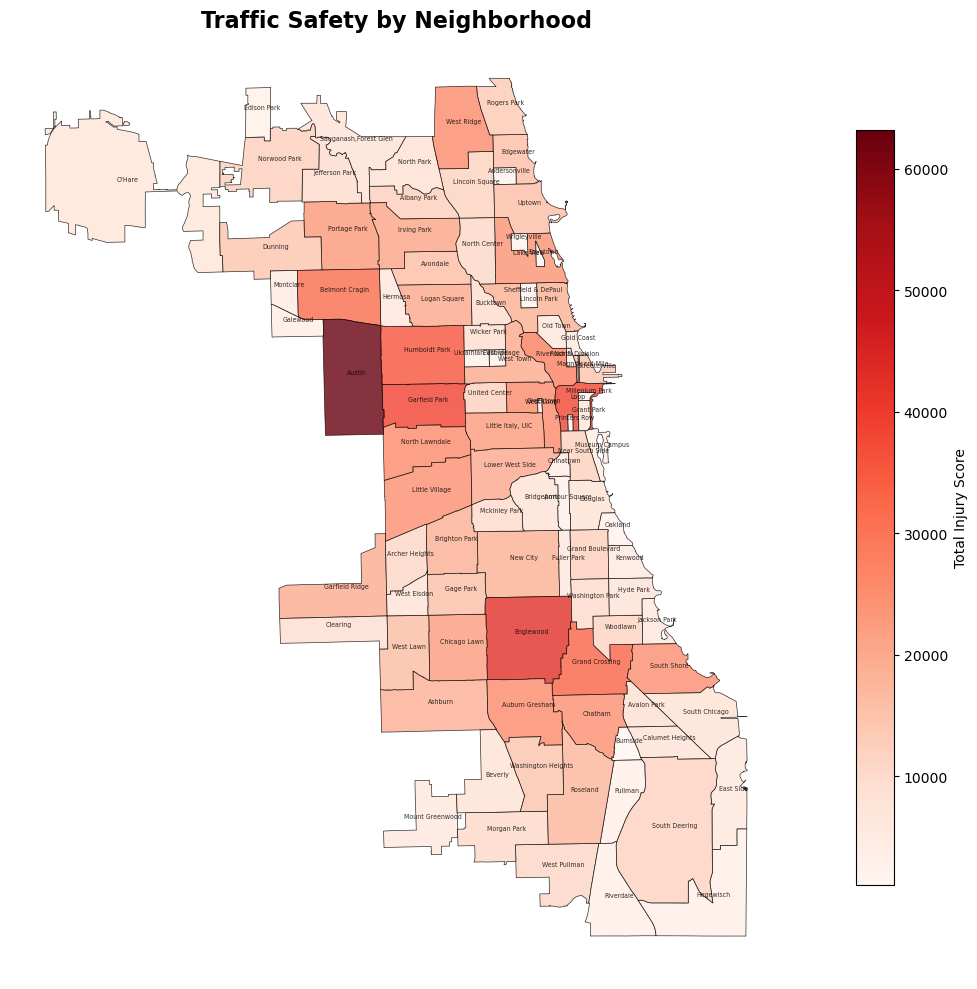

In [45]:
#|echo: false
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt

#amount of missing injury data
injury_columns = [
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION',
    'INJURIES_UNKNOWN'
]
crash_location_filtered[injury_columns].isna().any(axis=1).sum()

#filter out missing injury data
crash_injury_filtered = crash_location_filtered.dropna(subset=injury_columns).copy()
crash_injury_filtered.shape

negative_value_check = {}
for column in injury_columns:
    has_negative = (crash_injury_filtered[column]<0).any()
    negative_value_check[column] = has_negative
check_results = pd.Series(negative_value_check)

crash_injury_filtered['INJURIES_SCORE'] = crash_injury_filtered['INJURIES_FATAL']*4 + crash_injury_filtered['INJURIES_INCAPACITATING']*3 + crash_injury_filtered['INJURIES_NON_INCAPACITATING']*2 + \
crash_injury_filtered['INJURIES_REPORTED_NOT_EVIDENT']*1 + crash_injury_filtered['INJURIES_UNKNOWN']*1 + crash_injury_filtered['INJURIES_NO_INDICATION']*0.5



neighborhoods = pd.read_csv("Neighborhoods_2012b_20251209.csv")
neighborhoods['geometry'] = neighborhoods['the_geom'].apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(neighborhoods, geometry='geometry', crs='EPSG:4326')

crash_gdf = gpd.GeoDataFrame(
    crash_injury_filtered,
    geometry=gpd.points_from_xy(crash_injury_filtered.LONGITUDE, crash_injury_filtered.LATITUDE),
    crs="EPSG:4326"
)

neighborhoods_with_crashes = gpd.sjoin(
    gdf_neighborhoods, 
    crash_gdf, 
    how='left', 
    predicate='contains'
)

# Sum injury_score instead of counting crashes
injury_scores = neighborhoods_with_crashes.groupby(neighborhoods_with_crashes.index)['INJURIES_SCORE'].sum()
gdf_neighborhoods['Total Injury Score'] = injury_scores
gdf_neighborhoods['Total Injury Score'] = gdf_neighborhoods['Total Injury Score'].fillna(0)

name_column = 'PRI_NEIGH'
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf_neighborhoods.plot(
    column='Total Injury Score',
    ax=ax,
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'label': 'Total Injury Score',
        'orientation': 'vertical',
        'shrink': 0.8
    }
)

for idx, row in gdf_neighborhoods.iterrows():
    centroid = row.geometry.centroid
    
    if name_column in row:
        name = row[name_column]
    else:
        name = f"Neighborhood {idx}"
    
    ax.annotate(
        text=name,
        xy=(centroid.x, centroid.y),
        xytext=(3, 3),  
        textcoords="offset points",
        fontsize=4.5,
        alpha=0.8,
        ha='center'
    )

ax.set_title('Traffic Safety by Neighborhood', fontsize=16, fontweight='bold')
ax.set_axis_off()  
plt.tight_layout()
plt.show()

In [49]:
#|echo: false
gdf_neighborhoods.head()

,the_geom,PRI_NEIGH,SEC_NEIGH,SHAPE_AREA,SHAPE_LEN,geometry,crash_count
0,MULTIPOLYGON (((-87.60670812560372 41.81681377...,Grand Boulevard,BRONZEVILLE,"48,492,503.1554","28,196.837157","MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4...",8496
1,MULTIPOLYGON (((-87.62760697485348 41.87437097...,Printers Row,PRINTERS ROW,"2,162,137.97139","6,864.247156","MULTIPOLYGON (((-87.62761 41.87437, -87.6276 4...",853
2,MULTIPOLYGON (((-87.66706868914602 41.88885187...,United Center,UNITED CENTER,"32,520,512.7053","23,101.363745","MULTIPOLYGON (((-87.66707 41.88885, -87.66707 ...",8573
3,MULTIPOLYGON (((-87.65833494805533 41.92166144...,Sheffield & DePaul,SHEFFIELD & DEPAUL,"10,482,592.2987","13,227.049745","MULTIPOLYGON (((-87.65833 41.92166, -87.65835 ...",2004
4,MULTIPOLYGON (((-87.74059567509266 41.88782316...,Humboldt Park,HUMBOLDT PARK,"125,010,425.593","46,126.751351","MULTIPOLYGON (((-87.7406 41.88782, -87.7406 41...",25691


#### b) Analysis 2

#### Component 1
The data values for temperature, humidity, wind speed, precipitation rate and the posted speed limits of roads on crashes were binned into groups of 30 in order to analyze the average injury score of crashes within certain ranges of climate conditions. The relationship between average injury score and the other factors that may contribute to a crash were plotted via histogram.

Despite the large range of temperatures Chicago experiences, with an inter-quartile range of 20 degrees and a total range of 67 degrees Celsius, the correlation between the deadliness of a crash and weather values such as wind speed, temperature, precipitation, and humidity as well as posted speed limits is surprisignly small. The data showed a very slight correlation of 0.03 between the deadliness of crashes and the temperature of the crash event, which is small enough to be negligible; however, it is worth noting that average crash injury score continued to decrease as temperature dropped below zero Celsius; this is likely because adequate salting of roads prevents formation of ice over roads and drivers exhibit greater caution while driving in snowy terrain.

The correlation between humidity and average injury score as well as wind speed and average injury score were also incredibly small at -0.015 and -0.0015, respectively. As the Windy City, Chicago experiences a high range of wind speeds with a standard deviation of 8.23km/h and a range of over 60km/h of wind speeds; nevertheless, due to the high urbanization of Chicago, high winds are unlikely to affect cars between skyscrapers or create significant visibility problems via dust/snow to affect driver safety. Chicago also experiences high variability in humidity with a standard deviation of 17% and an interquartiler range between 48 and 75% humidity, but it still had a negligible impact on driver injury rates.

Surprisingly, precipitation rate had an incredibly minor correlation with average injury score at 0.0037. However, as precipitation rates increased past 30mm, the average injury score sharply increased to an average of 1.75 or more. This could indicate that precipitation rates have a relatively minor effect until 30mm of precipitation; this is when hydroplaning can begin to occur for vehicles [3], which would  explain the rapid increase in injury scores.

The posted speed limits of collisions, on the other hand, have a non-negligible positive correlation of 0.12. This suggests that while environmental factors have a surprisingly minimal correlation on injury severity, the infrastructure and regulations of the road play a greater role in crash outcomes. Higher posted speed limits cause drivers to drive faster and generate more kinetic energy on a crash, leading to a higher risk of injury or fatality to drivers and pedestrians. 

Altogether, weather is shown to have a relatively minor effect on the damage a vehicle crash causes; public services such as road salting as well as more cautious driving under inclement conditions can account for this. However, when drivers are allowed to drive faster, the danger in crashes increases noticeably. 

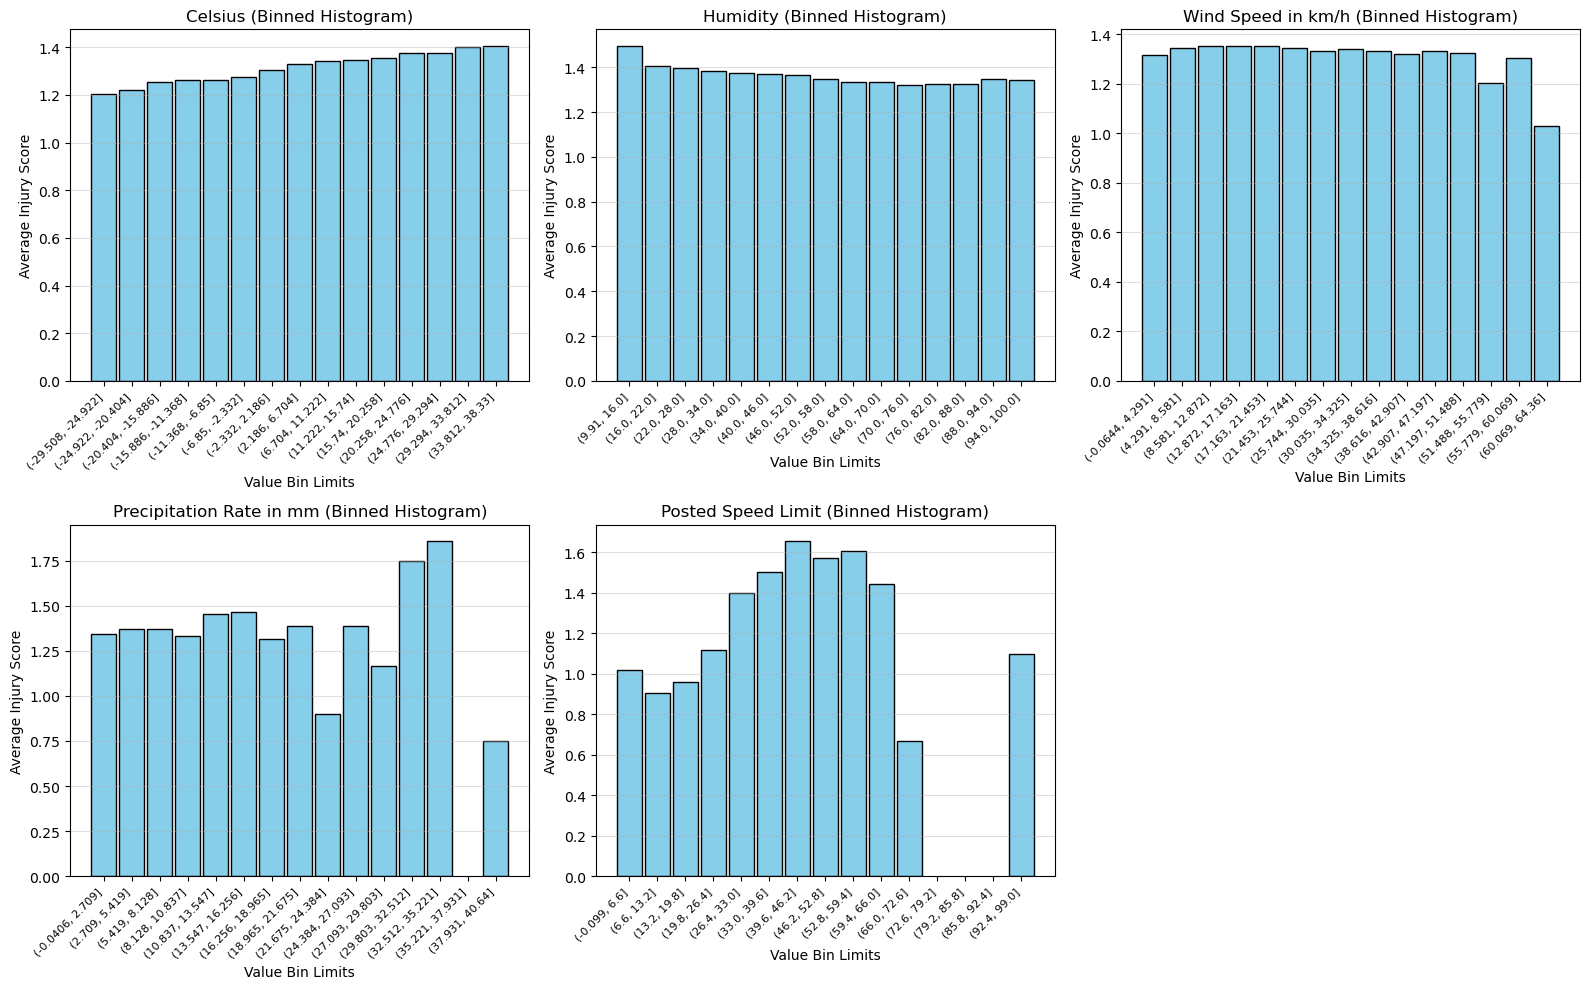

In [44]:
#|echo: false
import warnings
import numpy as np
warnings.simplefilter(action='ignore', category=FutureWarning)

weather = pd.read_csv('KMDW.csv')
weather['DateTime_String'] = weather['Date'].astype(str) + ' ' + weather['Time'].astype(str)

weather['US_Time'] = pd.to_datetime(weather['DateTime_String'], format = '%Y-%m-%d %I:%M %p')

crash_injury_filtered['US_Time'] = pd.to_datetime(
    crash_injury_filtered['CRASH_DATE'], 
    format='%m/%d/%Y %I:%M:%S %p'
)

weather = weather.sort_values(by = 'US_Time', ascending = True)
crash_injury_filtered = crash_injury_filtered.sort_values(by = 'US_Time', ascending = True)


from datetime import timedelta
merged_crash = pd.merge_asof(
    crash_injury_filtered, 
    weather, 
    on='US_Time', 
    direction='nearest', 
    tolerance=timedelta(minutes=120)
)

merged_crash = merged_crash.dropna(subset=['DateTime_String'])

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

num_weather_vars = [
    'Temperature_C',
    'Humidity_%',
    'Speed in km/h',
    'Precipitation Rate in mm',
    'POSTED_SPEED_LIMIT']

num_weather_vars_names = [
    'Celsius',
    'Humidity',
    'Wind Speed in km/h',
    'Precipitation Rate in mm',
    'Posted Speed Limit']
n = len(num_weather_vars)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

for ax, col, name in zip(axes, num_weather_vars, num_weather_vars_names):

    data = merged_crash[col]

    bins = pd.cut(data, bins=15)

    bin_means = merged_crash[[col, "INJURIES_SCORE"]].groupby(bins)["INJURIES_SCORE"].mean()

    ax.bar(
        x=range(len(bin_means)),
        height=bin_means.values,
        width=0.9,
        edgecolor="black",
        color="skyblue"
    )

    ax.set_xticks(range(len(bin_means)))
    ax.set_xticklabels(
        [str(interval) for interval in bin_means.index],
        rotation=45, ha="right", fontsize=8
    )

    ax.set_title(f"{name} (Binned Histogram)")
    ax.set_xlabel("Value Bin Limits")
    ax.set_ylabel("Average Injury Score")
    ax.grid(axis='y', alpha=0.4)

for i in range(len(num_weather_vars), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


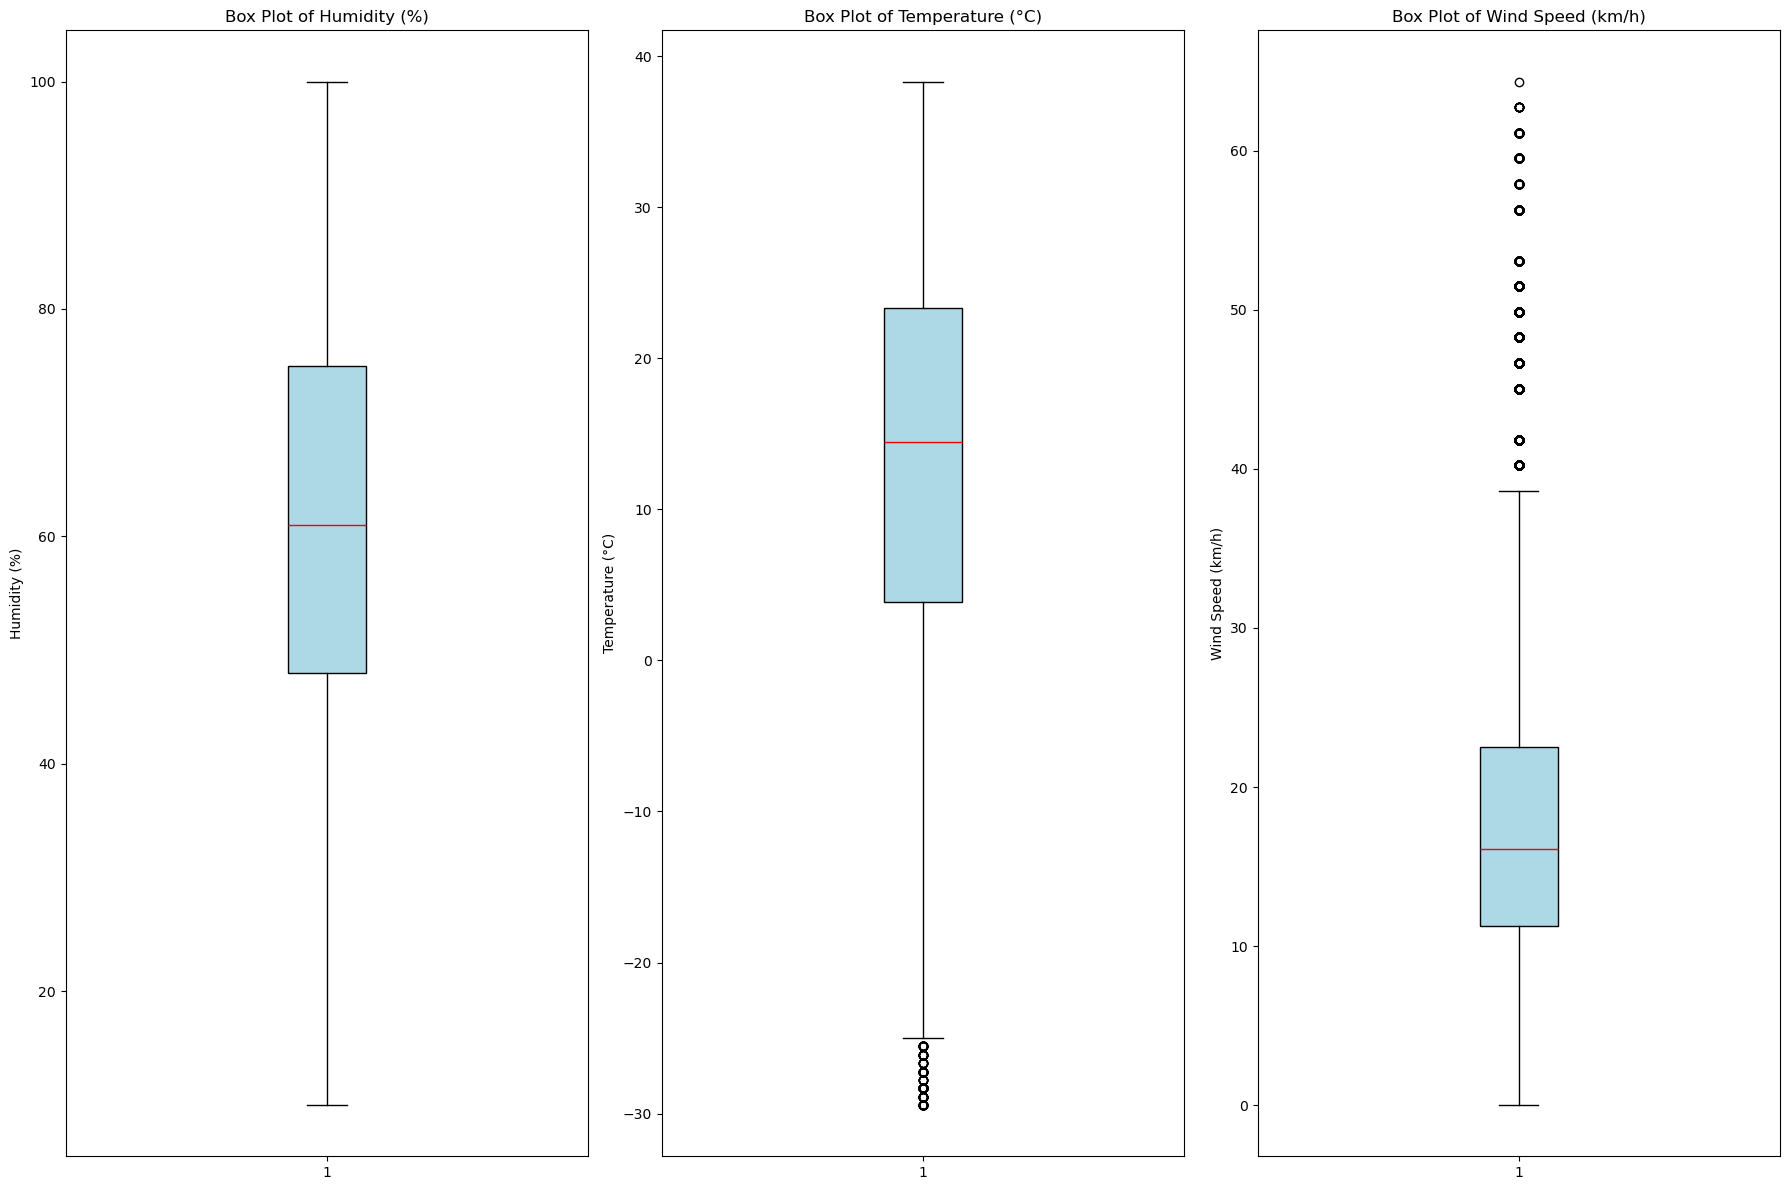

In [47]:
num_vars = [
    'Humidity_%',
    'Temperature_C',
    'Speed in km/h'
]

num_var_names = [
    'Humidity (%)',
    'Temperature (°C)',
    'Wind Speed (km/h)'
]

n = len(num_vars)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for ax, col, name in zip(axes, num_vars, num_var_names):

    data = merged_crash[col].dropna()

    bp = ax.boxplot(
        data,
        vert=True,
        patch_artist=True,      # allows facecolor
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="red"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black")
    )

    ax.set_title(f"Box Plot of {name}")
    ax.set_ylabel(name)

# Turn off unused axes
for i in range(len(num_vars), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [43]:
#|echo: false
for i in num_vars:
    data = merged_crash[i]

    print(data.describe())

Temperature_C
count    872839.000000
mean         13.382575
std          11.591353
min         -29.440000
25%           3.890000
50%          14.440000
75%          23.330000
max          38.330000
Name: Temperature_C, dtype: float64
Humidity_%
count    872839.000000
mean         61.421162
std          17.996642
min          10.000000
25%          48.000000
50%          61.000000
75%          75.000000
max         100.000000
Name: Humidity_%, dtype: float64
Speed in km/h
count    872839.000000
mean         17.063050
std           8.234937
min           0.000000
25%          11.260000
50%          16.090000
75%          22.530000
max          64.360000
Name: Speed in km/h, dtype: float64
Precipitation Rate in mm
count    872839.000000
mean          0.096517
std           0.807710
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          40.640000
Name: Precipitation Rate in mm, dtype: float64
POSTED_SPEED_LIMIT
count    872839.000000
mean  

### c) Analysis 3

#### Component 1)
Crash data was organized into months and the amount of crashes each month was plotted on a line chart for this component of the problem, with linear regression performed on the monthly crash count to deliver a trendline. Likewise, the average injury score of each month was recorded and plotted onto a line chart with linear regression done to deliver a trendline. On average, the number of crashes each month is decreasing by roughly 3.7 incidents. A significant drop in car crashes occurred during the start of 2020 due to the Coronavirus pandemic; however, the amount of crashes continued decreasing after 2022 with the average monthly crash amount dropping even faster at 3.93 less incidents per month. However, the average injury score of crashes has been increasing overtime, albeit at an extremely small pace of 0.0002 average injury score per month. In other words, the average car crash in Chicago has remained roughly the same over the last few years, and the amount of car crashes has been steadily decreasing overall, making it safer than ever to drive in Chicago.

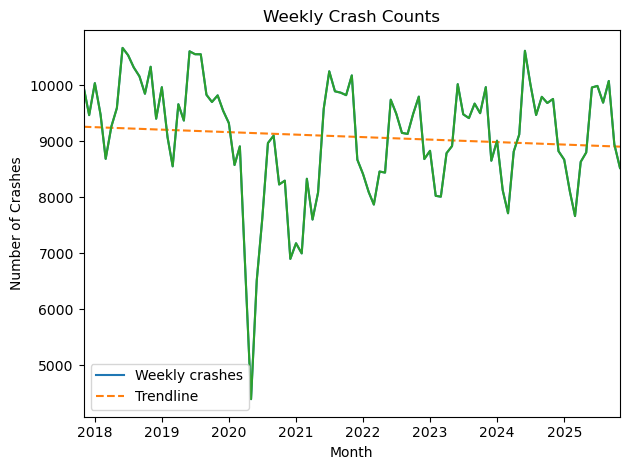

In [31]:
#|echo: false

crash_injury_filtered["CRASH_DATE"] = pd.to_datetime(crash_injury_filtered["CRASH_DATE"])

last_date = crash_injury_filtered["CRASH_DATE"].max()
last_date = pd.to_datetime(last_date)
last_month_start = last_date.replace(day=1)



crash_date_filtered = crash_injury_filtered[crash_injury_filtered["CRASH_DATE"] < last_month_start - timedelta(days=1)]

cutoff_date = pd.to_datetime('2017-10-01')

crash_date_filtered = crash_date_filtered[crash_date_filtered["CRASH_DATE"] >= cutoff_date]




crash_date_filtered["CRASH_DATE"] = pd.to_datetime(crash_date_filtered["CRASH_DATE"])

weekly_counts = (
    crash_date_filtered.resample("M", on="CRASH_DATE")
      .size()
      .reset_index(name="num_crashes")
)



x = np.arange(len(weekly_counts))
y = weekly_counts["num_crashes"].values

coef = np.polyfit(x, y, 1)
trend = coef[0] * x + coef[1]

weekly_counts["trendline"] = trend
plt.plot(weekly_counts["CRASH_DATE"], weekly_counts["num_crashes"], label="Weekly crashes")
plt.plot(weekly_counts["CRASH_DATE"], weekly_counts["trendline"], linestyle="--", label="Trendline")
plt.legend()


plt.plot(weekly_counts["CRASH_DATE"], weekly_counts["num_crashes"])
plt.xlabel("Month")
plt.ylabel("Number of Crashes")
plt.title("Weekly Crash Counts")
plt.xlim(weekly_counts["CRASH_DATE"].min(), weekly_counts["CRASH_DATE"].max())
plt.tight_layout()
plt.show()

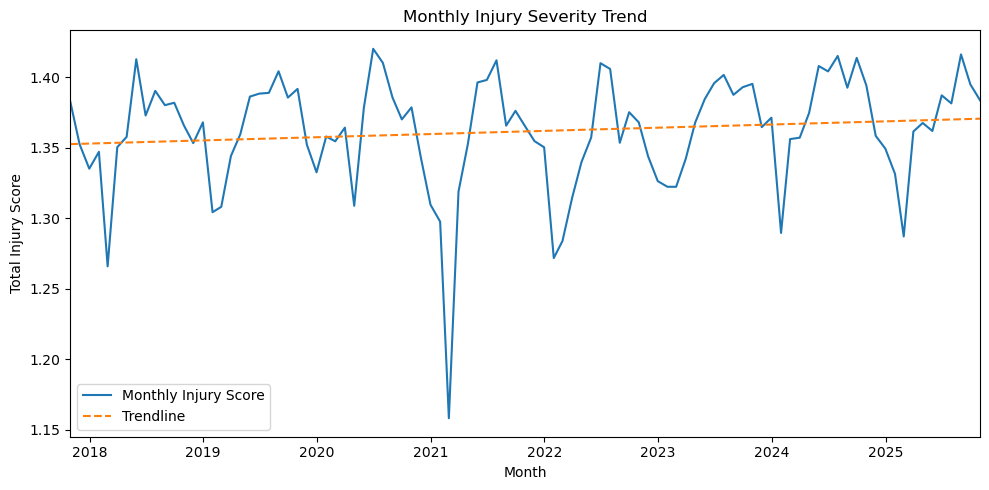

In [27]:
#|echo: false
monthly_injury = (
    crash_date_filtered.resample("M", on="CRASH_DATE")["INJURIES_SCORE"]
    .mean()
    .reset_index(name="injury_score")
)

# Compute trendline
x = np.arange(len(monthly_injury))
y = monthly_injury["injury_score"].values

coef = np.polyfit(x, y, 1)
trend = coef[0] * x + coef[1]

monthly_injury["trendline"] = trend

# Plot
plt.figure(figsize=(10, 5))
plt.plot(monthly_injury["CRASH_DATE"], monthly_injury["injury_score"], label="Monthly Injury Score")
plt.plot(monthly_injury["CRASH_DATE"], monthly_injury["trendline"], linestyle="--", label="Trendline")

plt.xlabel("Month")
plt.ylabel("Total Injury Score")
plt.title("Monthly Injury Severity Trend")
plt.legend()
plt.xlim(monthly_injury["CRASH_DATE"].min(), monthly_injury["CRASH_DATE"].max())
plt.tight_layout()
plt.show()


#### Component 2)
Crash data was organized into seasons based on their month and the amount of crashes each season was plotted on a line chart for this component of the problem. The safest time to drive in Chicago is during the winter seasons from December to February, with the average total injury score from a car crash being 1.32, and the most dangerous time to drive is during the summer seasoons from June to August with the average total injury score being 1.39. As many young drivers have more time to drive during the summer months, this may explain why the injury score is higher during these months. However, the relatively small gap of merely 0.07 average injury score between the two seasons indicates that driver safety is roughly identical between those 2 seasons. 

The amount of car crashes tells a similar story. In total, there were 203,631 crashes during the winter months and 233,011 crashes during the summer months in Chicago; therefore, the car crash amount data also suggests that it is safer to drive in Chicago during the winter compared to the summer, although this discrepancy in car crash amounts may be due to more vehicle traffic during the summer months. Overall, the average injury score of crashes and overall crash count indicate that summer is the season correlated with the most car crashes and the deadliest car crashes, while the winter is correlated with the least amount of car crashes and overall safer crashes. 

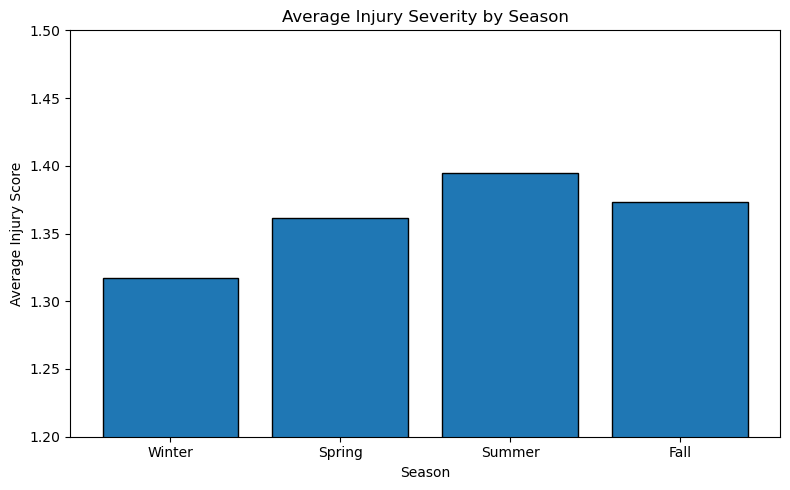

In [33]:
#|echo: false
monthly_injury = (
    crash_date_filtered
        .resample("M", on="CRASH_DATE")["INJURIES_SCORE"]
        .mean()
        .reset_index(name="injury_score")
)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

monthly_injury["Season"] = monthly_injury["CRASH_DATE"].dt.month.apply(get_season)

seasonal_injury = (
    monthly_injury.groupby("Season")["injury_score"]
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Fall"])  
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(seasonal_injury["Season"], seasonal_injury["injury_score"], edgecolor="black")

plt.xlabel("Season")
plt.ylabel("Average Injury Score")
plt.ylim(1.2, 1.5) 
plt.title("Average Injury Severity by Season")
plt.tight_layout()
plt.show()


In [36]:
#|echo: false
seasonal_injury.head()

,Season,injury_score
0,Winter,1.316814
1,Spring,1.361230
2,Summer,1.394585
3,Fall,1.373639


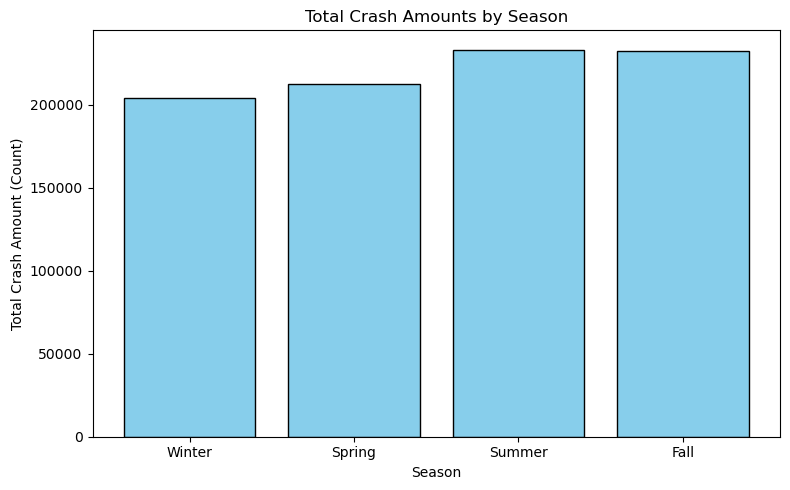

In [34]:
#|echo: false
monthly_crash = (
    crash_date_filtered.set_index("CRASH_DATE")
    .resample("M")
    .size()
    .reset_index(name="monthly_crash_count")
)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

monthly_crash["Season"] = monthly_crash["CRASH_DATE"].dt.month.apply(get_season)

seasonal_crash_totals = (
    monthly_crash.groupby("Season")["monthly_crash_count"]
    .sum()
    .reindex(["Winter", "Spring", "Summer", "Fall"])
    .reset_index(name="total_crashes")
)

plt.figure(figsize=(8, 5))
plt.bar(
    seasonal_crash_totals["Season"], 
    seasonal_crash_totals["total_crashes"], 
    color='skyblue', # Added color
    edgecolor="black"
)

plt.xlabel("Season")
plt.ylabel("Total Crash Amount (Count)") # Corrected label
plt.title("Total Crash Amounts by Season")
plt.tight_layout()
plt.show()

In [42]:
#|echo: false
seasonal_crash_totals.head()

,Season,total_crashes
0,Winter,203631
1,Spring,212238
2,Summer,233011
3,Fall,231988


## 7) Recommendations to Stakeholders

### a) Recommendations 1

Drivers and visitors to the Chicago area who are driving would do well to avoid areas such as western neighborhoods like Austin, southern neighborhoods like Englewood, and The Loop, as these areas exhibit the crashes with the highest average injury rates as well as the most crashes overall. City officials should pay special attention to these areas and station more traffic cops and infrastructure such as stop signs in these neighborhoods.

There are some limitations to the heatmap, mainly that crashes which concentrate on the border of a neighborhood may create the illusion that one neighborhood is extremely dangerous to drive in while the nearby one is safer, even though drivers in the latter neighborhood may need to drive through the dangerous areas anyways. Dividing each neighborhood into smaller categories and plotting a heatmap of the data would help overcome this limitation somewhat.

### b) Recommendations 2

Drivers and visitors to the Chicago area who are driving should not be overly concerned with inclement weather such as high wind speeds, snow or low temperatures when driving, as there is relatively small correlation between these factors and the deadliness of a car crash. However, they should be more cautious when driving in areas with high speed limits as there is a notable positive correlation between high speed limits and crash deadliness. City officials should be more wary of posting speed limits that are higher than necessary.

The main limitation of this data is it is unable to determine why driver crashes in inclement weather are not correlated with weather conditions. It could be that weather effects simply do not play a significant role in car crashes; alternatively, it could be because drivers are being more cautious when driving in these conditions. Surveying how much drivers pay attention to the road could provide data that clears up this limitaiton.

### c) Recommendations 3

Drivers and city officials should not worry about Chicago becoming more dangerous to drive, as driving in Chicago has become safer than ever, with average car crash deadliness remaining virtually flat and car crash numbers steadily decreasing over the years. Drivers who want to ensure the absolute safest possible driving in Chicago should drive in the winter, as there are less car crashes and less severe injuries on average in this season. However, the overall correlation between season and driver crash injuries or car crash totals is relatively weak. The car crash rate cannot be determined by this data due to the lack of data around total vehicular miles traveled each season; if this data were attainable, it would be possible to determine which seasons have the lowest rate of car crashes overall.

## 8) Conclusion

Driving is becoming safer overall in Chicago, but there are still thousands of crashes and fatalities happening a month that don't need to. The key insight revealed by synthesizing all analyses in this report is that crash risk in Chicago is primarily a function of location and infrastructure rather than time or weather. The path to significantly reducing car crash injuries in Chicago lies in transforming the road network's built environment and not merely managing driver behavior in response to external conditions. While neighborhood locations and speed limits play a large role in determing where and how car crashes occur, seasonal differences and weather conditions that are more dynamic play a very minor role. In other words, city officials should be proactive about reducing speed limits and targeting neighborhoods like The Loop, Englewood and Austin, and less concerned with how seasonal differences or weather conditions impact driving safety.

## References


[1] Chicago Data Portal. Traffic Crashes - Crashes. https://data.cityofchicago.org/Transportation/Traffic-Crashes-Crashes/85ca-t3if/about_data

[2] Weather Underground. Chicago, IL Weather History https://www.wunderground.com/history/daily/us/il/chicago/KMDW 


[3] Barksdale, Martha. How Hydroplaning Works. https://auto.howstuffworks.com/car-driving-safety/accidents-hazardous-conditions/hydroplaning.htm

[4] Chicago Data Portal. Boundaries - Neighborhoods, 2025. https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Neighborhoods/bbvz-uum9

[5] Yucy. Most Dangerous Neighborhoods in Chicago. https://reolink.com/blog/most-dangerous-neighborhoods-in-chicago/